In [117]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Model Complexity and Overfitting

**Overview**
In this exercise you will experiment with the impact of model complexity (higher order polynomial) and how it relates to Occam's Razor. 


<article class="message">
    <div class="message-body">
        <strong>List of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#poly_re">Task 1:  Polynomial regression</a>
            </li>
            <li>
            <a href="#occam_train">Task 2: Train and evaluate linear models with po…</a>
            </li>
            <li>
            <a href="#plot_results">Task 3: Plot the polynomials (models)</a>
            </li>
            <li>
            <a href="#reflection">Task 4: Reflection</a>
            </li>
            <li>
            <a href="#Different_data_func">Task 5: Changing the data generating function</a>
            </li>
        </ul>
    </div>
</article>

<div style="float: right; width: 50%; justify-content: start" class="block is-clearfix">

<div class="has-text-centered">
<figure class="image is-inline-block" >

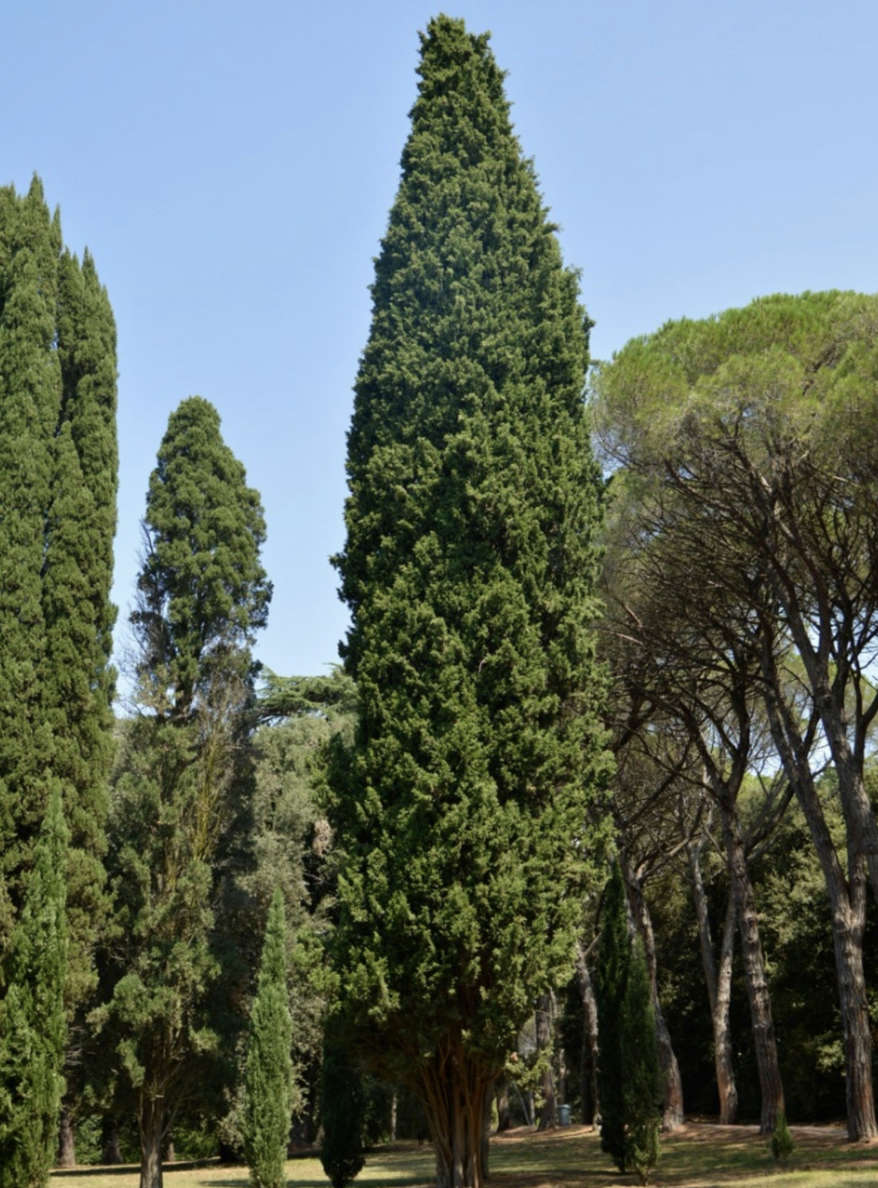


</figure>
</div>


</div>

This exercise is about making a regression model to predict the growth of Thuja Green Giant trees. You have to help the scientists decide which polynomial order best represents the training data to estimate future growth. To determine the optimal fit (model parameters), another group of researchers have provided you with  observation of height of their Thuja Green Giant trees from years later than currently observed by your team (`X_test`
 and `y_test`
). You will use this to choose the optimal model representing the growth of the Thuja Green Giant.
## Data
The following cell constructs and shows the data for the exercise. The data simulates growth (in meters) of one of the fastest growing trees, the Thuja Green Giant, each year. Scientists have observed and reported the growth of the tree for 7 years (`X_train`
 and `y_train`
), and now want to predict the future growth. 
The objective is to assist in making predictions based on this data. Additional data from another group has been provided to validate the hypothesis.
The scientists assume a polynomial relationship. 


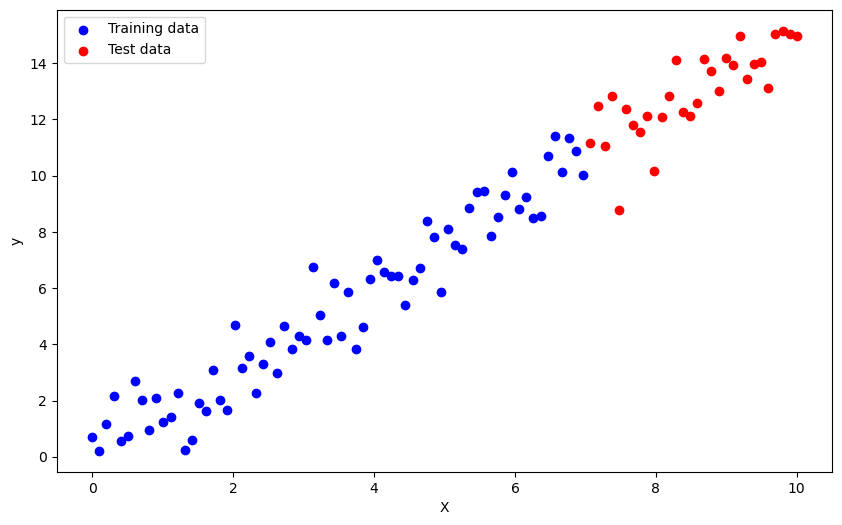

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 100
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = 1.5 * X.ravel() + 0.2 # Original relationship 
#y_true = X.ravel()**2 + 1.5 * X.ravel() - 3 # Changed to this relationship in task 5 (second order polynomial)
noise = np.random.normal(0, 1, n_samples)
y = y_true + noise

# Split the data into training and test sets
split_index = int(0.7 * n_samples)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()


---
**Task 1 (easy):  Polynomial regression👩‍💻**
1. In this exercise you may reuse polynomial regression using least squares
 from the previous exercise, or use the `PolynomialFeatures()`
 method from the [scikit-learn library](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
 to implement the `polynomial_regression()`
 method in the cell below. 


---

In [119]:
from sklearn.model_selection import train_test_split


def polynomial_regression(X, y, degree):
    """
    Create and train a model of desired order and use it to predict the growth of the trees.

    :param X: Vector of combined observed years).
    :param y: Vector of combined observed height.
    :param degree: Degree of the model.
    
    :return: Vector containing prediction for training data, vector containing prediction for test data.
    """
#write code/solution here ...

    #Split data into training and test sets
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree) # we want to create polynomial features of the specified degree (e.g., for degree=3 we get 1, x, x^2, x^3)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create and train the model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    return y_train_pred, y_test_pred


---
**Task 2 (easy): Train and evaluate linear models with polynomial features👩‍💻**
1. Use the function `polynomial_regression`
 to perform polynomial regression for each order defined in the `degrees`
 variable and predict the outcome for both the test and training data. 
2. Implement the function `compute_mse`
 that based on the predictions of a model and the ground truth targets returns the _mean-squared-error_.


$$ MSE = \frac{1}{m}\sum_{i=1}^{m}(f_{\mathbf{w}}(x_{i})-y_{i})^2$$

**Hint**
You may save some time by modifying the implementation of the `rmse`
 function from the previous exercise.

3. For each polynomial model calculate the _mean-squared-error_ for both the training and test data (use `polynomial_regression`
 and `compute_mse`
).


---

In [120]:
def compute_mse(y_true, y_pred):
    """Compute Mean Squared Error between true and predicted values."""
    #write code/solution here ... 
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

# Train and evaluate linear models with different polynomial features

degrees = [1, 2, 3, 4, 5, 6]
train_pred = []
test_pred = []
train_error = []
test_error = []

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#write code/solution here ...
for degree in degrees:
    y_train_pred, y_test_pred = polynomial_regression(X, y, degree)
    train_pred.append(y_train_pred)
    test_pred.append(y_test_pred)
    train_error.append(compute_mse(y_train, y_train_pred))
    test_error.append(compute_mse(y_test, y_test_pred))



---
**Task 3 (easy): Plot the polynomials (models)👩‍💻**
Run the cell below to:
1. Plot the data so that training and test data have different colors.
2. Plot the predictions of the polynomial models over the scatter plot showing the given data. Perform this for both the training and test sets using X as input.


---

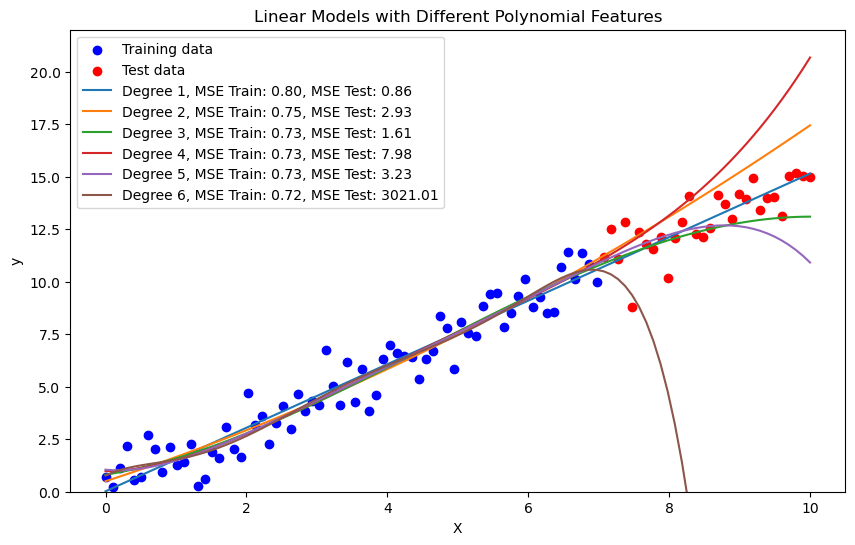

In [121]:
# Plot the results

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')

for i, degree in enumerate(degrees):
    plt.plot(X, np.concatenate((train_pred[i],test_pred[i])), label=f'Degree {degree}, MSE Train: {train_error[i]:.2f}, MSE Test: {test_error[i]:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(0,22) # Keep axis fixed in a plot (add this line when looking at the original plot (first order polynomial), but remove for the second order polynomial)
plt.legend()
plt.title('Linear Models with Different Polynomial Features')
plt.show()
# Insert code for question 1
# The following line keep axis fixed in a plot
#plt.ylim(0,30)
# Insert code for question 2


---
**Task 4 (medium): Reflection💡**
Reflect on:
1. Which model had the best performance  on the training data?
2. Which model had the best performance  on the test data?
3. How does the complexity (degree) of the model affect the performance on the training and test data?
4. Which model(s) shows signs of overfitting? How can you tell?


---

In [122]:
# Write reflection here
#1. Which model had the best performance  on the training data?
# The 6-order model performed best on the training data (with the lowest MSE of them all on the training set) 

#2. Which model had the best performance  on the test data?
# The 1-order model had the best performance on the test data (lowest MSE of all on the test set)

#3. How does the complexity (degree) of the model affect the performance on the training and test data?
# As the degree of the model increases, the training error (MSE) decreases, indicating that the model is fitting the training data better. This is expected as the model becomes more flexible and can capture more complex patterns in the training data.
# However, the test error (MSE) does not necessarily decrease with increasing complexity; in fact, it may increase (like here) after a certain point, indicating that the model is overfitting the training data and not generalizing well to unseen data.

#4. Which model(s) shows signs of overfitting? How can you tell?
# I would say that it is actually only the 1-order model that does not show signs of overfitting.
# The 6-order model clearly shows signs of overfitting.
# This is evident from the fact that while it has the lowest training error, its test error is extremely high.
# We can also see it in the plot, where the 6-order polynomial curve fits the training data very closely but makes a sudden drop later on, with no motivation from the data points.
# The other models (2nd to 5th order) also show signs of overfitting, as their test errors are higher than that of the 1-order model, despite having lower training errors, but they are not as extreme as the 6-order model. 
# For these, it is more clear from the plot than the MSE values alone. 
# In the plot we see that the curves for these models start to show more fluctuations and deviations from the general trend of the data later on, without any data points to support these fluctuations.


---
**Task 5 (medium): Changing the data generating function👩‍💻💡**
How do the results change if the underlying function generating the data was changed to a 2. order polynomial, so that it e.g. simulates bacteria growth instead? 
1. Re-generate the data by replacing `y_true`
 with $y=f(x)=x^2+1.5x-3$ in the data generation step, and rerun the other code blocks.
2. Does it still make sense to follow the strategy of Occam's razor?


---

In [123]:
# Write reflection

#From google: 
# Occam's Razor is the principle that when multiple models accurately explain the data, 
# the simplest model (with fewer assumptions, parameters, or complexity) is usually the best choice 
# because it's more likely to generalize well to new, unseen data and less prone to overfitting

# 1 
# See the results below (y_true = ... has been changed in the code in the beginning)

# 2
# Yes, it still makes sense to apply Occam's Razor here.
# The 1-order model is still the simplest model, but it does not perform as well on the training data as the more complex models anymore. 
# The higher order models has significantly lower training errors (MSE) compared to the 1-order model, indicating that they fit the training data better.
# On the test data, the 3-order model now performs best, but not much better than the 2-order model. 
# Since the 2-order model is simpler than the 3-order model, and still performs well on the test data, it would be a better choice according to Occam's Razor.

**Plot-result after changing to second order polynomial:**

![Image of plot-result after changing to second order polynomial](output2order.png)